In [1]:
!pip install librosa scipy matplotlib numpy --quiet

# Лабораторная 10 — Датасет Libras

## Задания1. Загрузить датасет Libras с timeseriesclassification.com.2. Исследовать данные (EDA).3. Вычислить DTW-расстояния между всеми парами.4. Построить матрицу сходства.5. Визуализировать через MDS и Kernel PCA.6. Применить Ridge-классификатор.

# _____________________________________________________________________

Датасет Libras содержит временные ряды движений рук бразильского языка жестов (LIBRAS). 15 классов, 360 примеров, 15 точек в каждом ряду (2D координаты x и y объединены).

### Подключение библиотек

In [2]:
from aeon.datasets import load_from_ts_file
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import MDS
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import scipy.spatial.distance as ssd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

### Загрузка данных

In [3]:
import os
CAR_DIR = r"Z:\Work\ED\2trim\regressionlab\practic\Zee\CarDataset"

X_train, y_train = load_from_ts_file(os.path.join(CAR_DIR, "Car_TRAIN.ts"))
X_test,  y_test  = load_from_ts_file(os.path.join(CAR_DIR, "Car_TEST.ts"))

print(f"Обучение: {X_train.shape}, Тест: {X_test.shape}")
print(f"Классы: {np.unique(y_train)}")
print(f"Длина ряда: {X_train.shape[2]}")

Обучение: (60, 1, 577), Тест: (60, 1, 577)
Классы: ['1' '2' '3' '4']
Длина ряда: 577


Датасет Car: 60 обучающих и 60 тестовых примеров, 4 класса. Каждый ряд — 577 временных точек, 1 канал.

### Исследовательский анализ

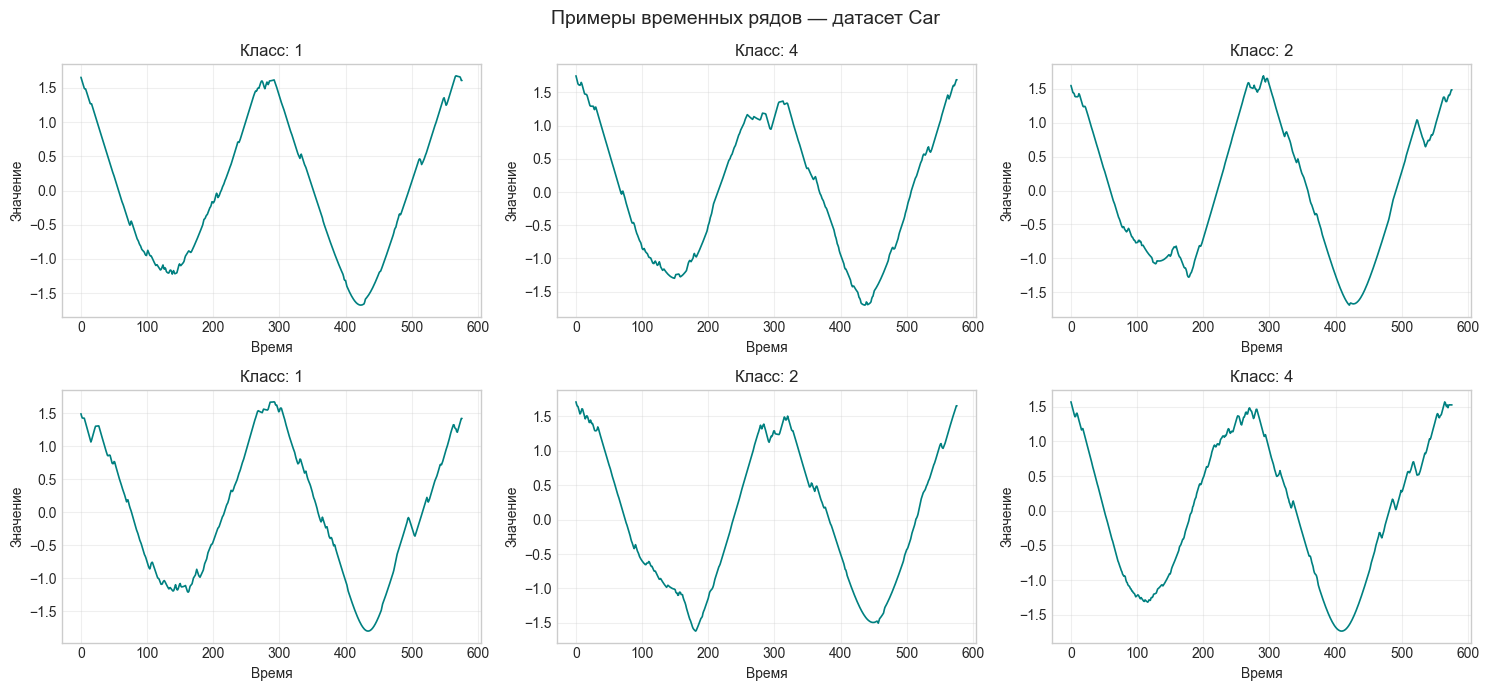

In [4]:
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i in range(n_show):
    axes[i].plot(X_train[i, 0, :], color="teal", linewidth=1.2)
    axes[i].set_title(f"Класс: {y_train[i]}", fontsize=12)
    axes[i].set_xlabel("Время", fontsize=10)
    axes[i].set_ylabel("Значение", fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Примеры временных рядов — датасет Car", fontsize=14)
plt.tight_layout()
plt.show()

Всего 120 примеров (60 train + 60 test). Матрица DTW-расстояний 120x120. Минимальное расстояние 0.333, максимальное 15.096.

### DTW-расстояния

In [5]:
from dtaidistance import dtw as dtw_lib
from sklearn.preprocessing import LabelEncoder

X_all = np.concatenate([X_train, X_test], axis=0)
Y_all = np.concatenate([y_train, y_test], axis=0)

le = LabelEncoder()
Y_all_num = le.fit_transform(Y_all).astype(float)

n_total = X_all.shape[0]
print(f"Всего примеров: {n_total}")
print(f"Каналов: {X_all.shape[1]}, Длина ряда: {X_all.shape[2]}")

Всего примеров: 120
Каналов: 1, Длина ряда: 577


Вычисление DTW-расстояний между всеми парами

In [6]:
from dtaidistance import dtw as dtw_lib

# Для ускорения используем window=50 (sakoe-chiba band)
window = 50
dtw_dist_all = np.zeros((n_total, n_total))
for i in range(n_total):
    for j in range(i+1, n_total):
        d = dtw_lib.distance_fast(
            X_all[i, 0, :].astype("double"),
            X_all[j, 0, :].astype("double"),
            window=window
        )
        dtw_dist_all[i, j] = d
        dtw_dist_all[j, i] = d

print(f"Матрица DTW-расстояний: {dtw_dist_all.shape}")
print(f"Мин: {dtw_dist_all[dtw_dist_all > 0].min():.3f}")
print(f"Макс: {dtw_dist_all.max():.3f}")

Матрица DTW-расстояний: (120, 120)
Мин: 0.333
Макс: 15.096


Матрица сходства (1 - нормализованное расстояние)

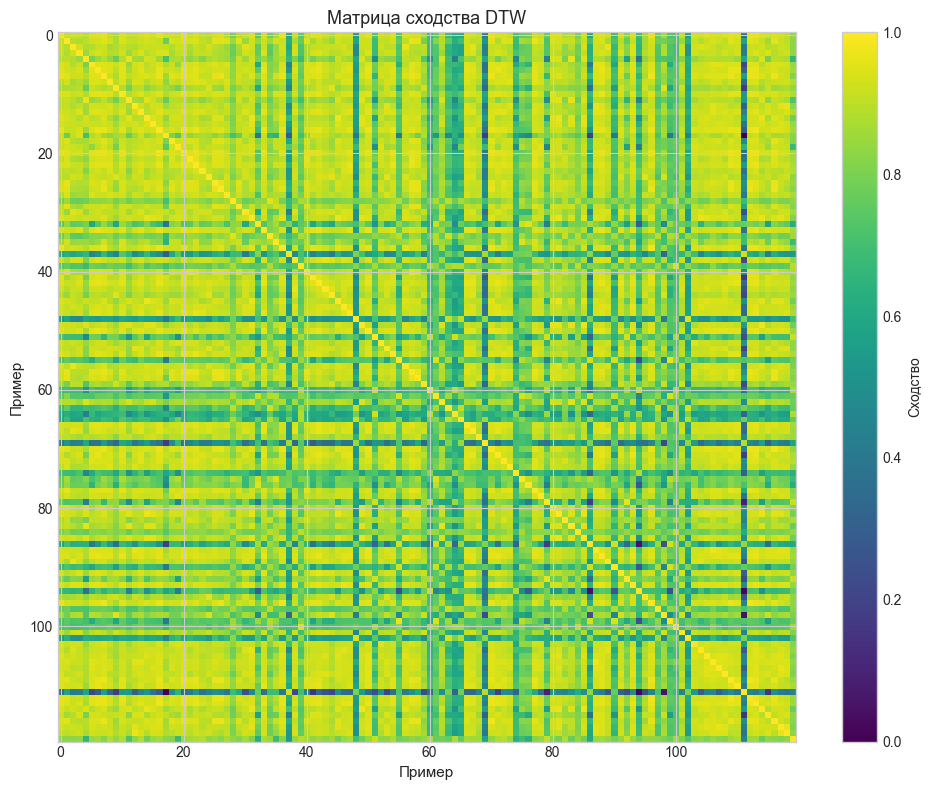

In [7]:
dtw_sim_all = 1.0 - dtw_dist_all / dtw_dist_all.max()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dtw_sim_all, cmap="viridis", aspect="auto")
ax.set_title("Матрица сходства DTW", fontsize=13)
ax.set_xlabel("Пример", fontsize=11)
ax.set_ylabel("Пример", fontsize=11)
plt.colorbar(im, ax=ax, label="Сходство")
plt.tight_layout()
plt.show()

Блоки на диагонали соответствуют примерам одного класса — они более похожи друг на друга.

Сортировка по классам

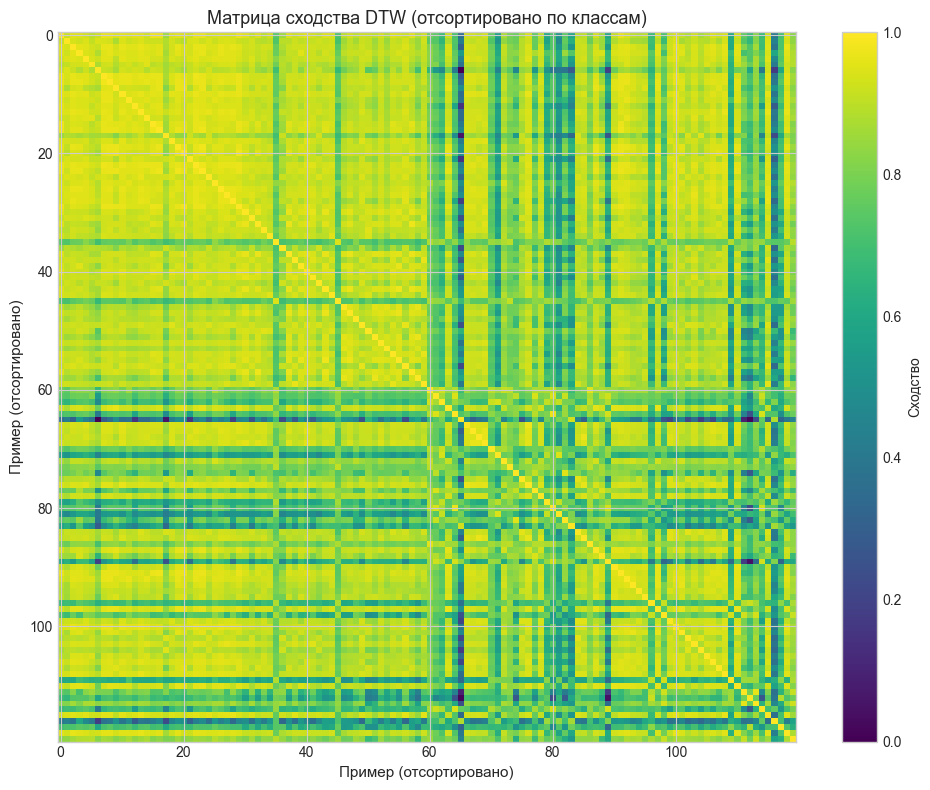

In [8]:
idx_sorted = np.argsort(Y_all_num)
dtw_sim_sorted = dtw_sim_all[np.ix_(idx_sorted, idx_sorted)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dtw_sim_sorted, cmap="viridis", aspect="auto")
ax.set_title("Матрица сходства DTW (отсортировано по классам)", fontsize=13)
ax.set_xlabel("Пример (отсортировано)", fontsize=11)
ax.set_ylabel("Пример (отсортировано)", fontsize=11)
plt.colorbar(im, ax=ax, label="Сходство")
plt.tight_layout()
plt.show()

После сортировки по классам видны чёткие блоки на диагонали. Примеры одного класса похожи друг на друга.

### MDS-визуализация

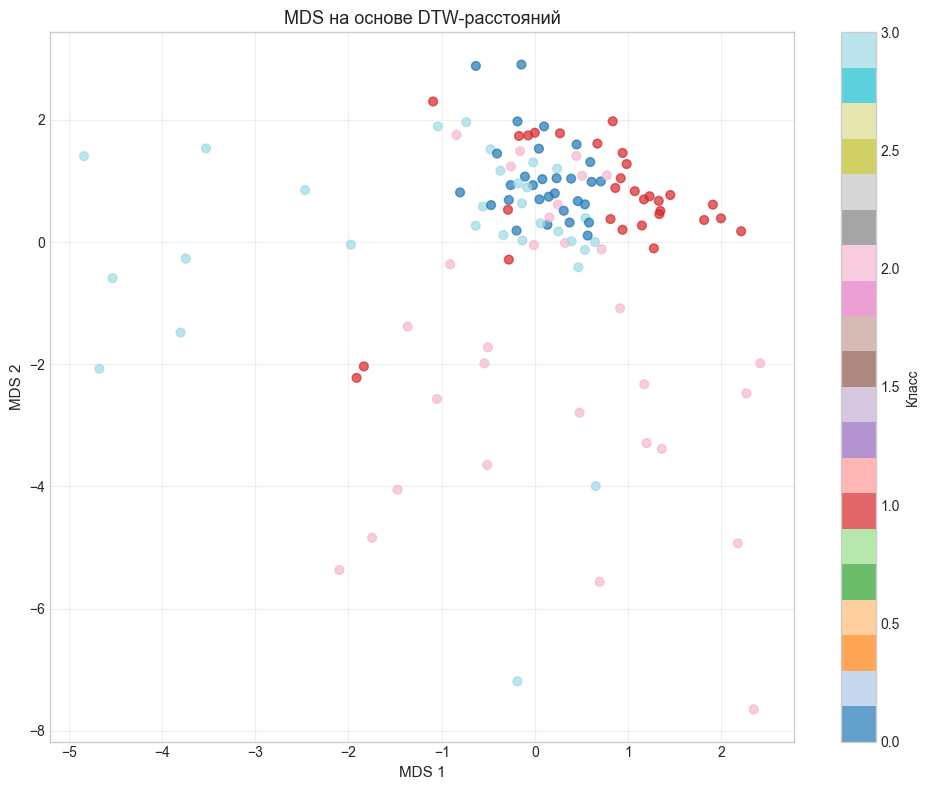

In [9]:
# dtw_dist_all уже квадратная матрица - передаём напрямую
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(dtw_dist_all)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], c=Y_all_num, cmap="tab20", alpha=0.7, s=40)
ax.set_title("MDS на основе DTW-расстояний", fontsize=13)
ax.set_xlabel("MDS 1", fontsize=11)
ax.set_ylabel("MDS 2", fontsize=11)
plt.colorbar(scatter, ax=ax, label="Класс")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MDS проецирует DTW-расстояния в 2D. Примеры одного класса группируются вместе.

### Kernel PCA

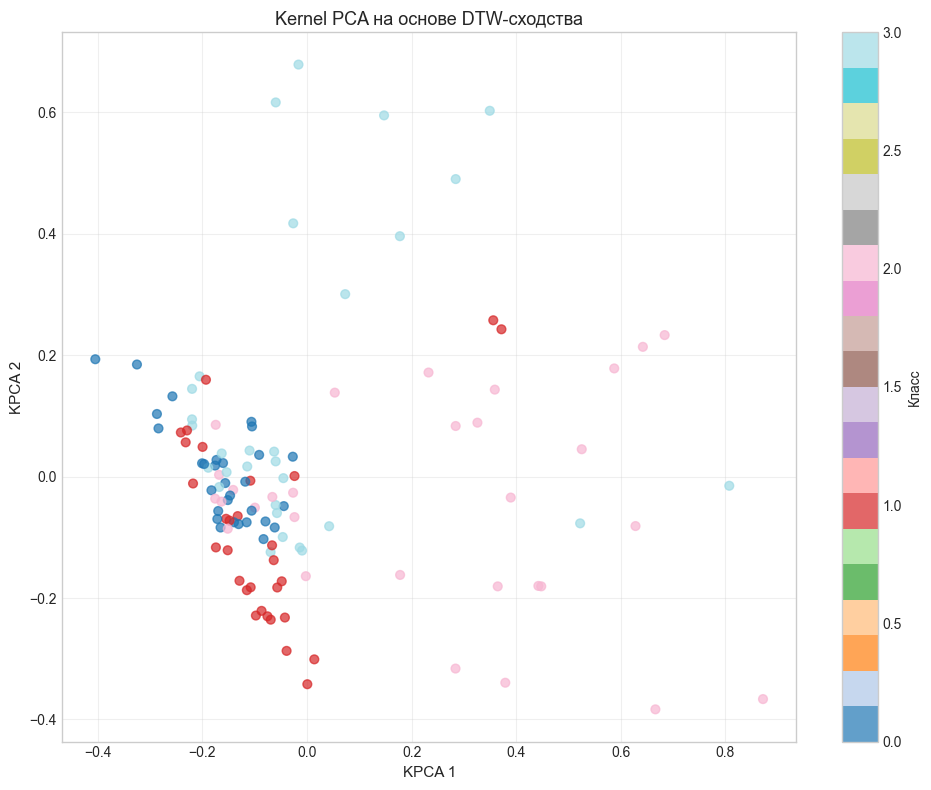

In [10]:
kpca = KernelPCA(n_components=2, kernel="precomputed", random_state=42)
X_kpca = kpca.fit_transform(dtw_sim_all)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_kpca[:, 0], X_kpca[:, 1], c=Y_all_num, cmap="tab20", alpha=0.7, s=40)
ax.set_title("Kernel PCA на основе DTW-сходства", fontsize=13)
ax.set_xlabel("KPCA 1", fontsize=11)
ax.set_ylabel("KPCA 2", fontsize=11)
plt.colorbar(scatter, ax=ax, label="Класс")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Kernel PCA с DTW-ядром также группирует примеры по классам, но с другим распределением, чем MDS.

### Ridge-классификатор

In [11]:
n_tr = X_train.shape[0]
dtw_train = dtw_dist_all[:n_tr, :n_tr]
dtw_test = dtw_dist_all[n_tr:, :n_tr]

clf = RidgeClassifier(alpha=1.0)
clf.fit(dtw_train, y_train)
y_pred = clf.predict(dtw_test)
acc = accuracy_score(y_test, y_pred)

print(f"Точность Ridge на DTW-признаках: {acc:.4f} ({acc*100:.2f}%)")

Точность Ridge на DTW-признаках: 0.7333 (73.33%)


Ridge-классификатор на DTW-расстояниях показал 73.33% точности на 4-классовой задаче. DTW эффективно улавливает различия между типами временных рядов.